# Data Preprocessing
Prepare the data for model training.

In [1]:
# ================================
# DATA HANDLING
# ================================
import pandas as pd
import numpy as np


# ================================
# VISUALIZATION (optional but useful)
# ================================
import matplotlib.pyplot as plt
import seaborn as sns


# ================================
# SKLEARN PREPROCESSING
# ================================
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)


# ================================
# TRAIN TEST SPLIT
# ================================
from sklearn.model_selection import train_test_split


# ================================
# HANDLE IMBALANCED DATA
# ================================
from imblearn.over_sampling import SMOTE


# ================================
# SAVE PREPROCESSING OBJECTS
# ================================
import joblib


# ================================
# OPTIONAL PIPELINE UTILITIES
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Load dataset
df = pd.read_csv("eda_cleaned.csv")
print(df.head())

   Age  Gender         Country self_employed family_history treatment  \
0   37  Female   United States            No             No       Yes   
1   44       M   United States            No             No        No   
2   32    Male          Canada            No             No        No   
3   31    Male  United Kingdom            No            Yes       Yes   
4   31    Male   United States            No             No        No   

  work_interfere    no_employees remote_work tech_company  ...   anonymity  \
0          Often            6-25          No          Yes  ...         Yes   
1         Rarely  More than 1000          No           No  ...  Don't know   
2         Rarely            6-25          No          Yes  ...  Don't know   
3          Often          26-100          No          Yes  ...          No   
4          Never         100-500         Yes          Yes  ...  Don't know   

                leave mental_health_consequence phys_health_consequence  \
0       Somewhat 

In [3]:
df.sample(25)


,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
743,31,Male,United States,No,Yes,Yes,Sometimes,26-100,No,Yes,...,Don't know,Somewhat easy,Maybe,No,Some of them,Yes,Maybe,Yes,Don't know,No
219,41,Male (CIS),United States,No,No,No,Unknown,26-100,No,Yes,...,Don't know,Very easy,Yes,No,No,Some of them,No,No,Don't know,No
950,34,Male,Netherlands,No,No,Yes,Rarely,26-100,No,Yes,...,Yes,Very easy,No,No,Yes,Yes,Maybe,Maybe,Yes,No
171,31,Male,United Kingdom,Yes,No,Yes,Often,6-25,No,Yes,...,Don't know,Don't know,Maybe,No,Some of them,Yes,No,Maybe,Don't know,No
283,35,male,United States,No,Yes,Yes,Sometimes,26-100,No,Yes,...,Yes,Somewhat difficult,Yes,No,No,Some of them,No,Maybe,Don't know,No
1009,44,F,United States,No,No,No,Unknown,100-500,No,Yes,...,Don't know,Don't know,Yes,No,No,No,No,No,Don't know,No
1075,40,Male,United States,No,Yes,Yes,Sometimes,More than 1000,No,Yes,...,Yes,Don't know,Yes,Yes,No,No,No,Maybe,No,Yes
253,27,Male,United Kingdom,No,No,No,Unknown,100-500,No,No,...,No,Very easy,Maybe,Maybe,Yes,Yes,No,No,Don't know,No
199,28,Male,United Kingdom,No,Yes,Yes,Sometimes,More than 1000,No,Yes,...,Don't know,Don't know,Maybe,Maybe,Some of them,No,No,Maybe,Don't know,No
69,34,Male,United States,Yes,No,No,Rarely,1-5,Yes,Yes,...,Don't know,Don't know,Maybe,No,Some of them,No,No,No,Don't know,No


In [4]:
df["treatment"].value_counts()

treatment
Yes    637
No     622
Name: count, dtype: int64

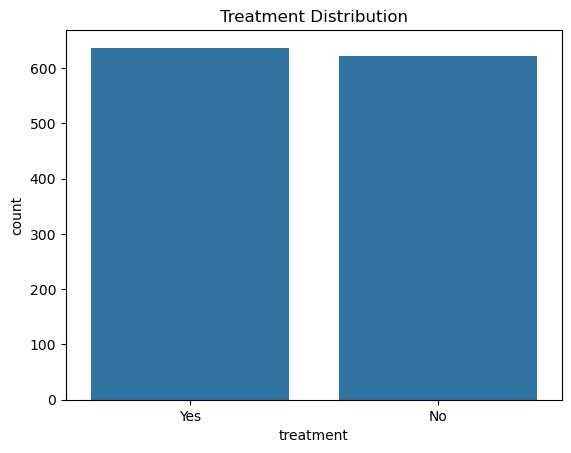

In [5]:
sns.countplot(x="treatment", data=df)

plt.title("Treatment Distribution")
plt.show()

In [12]:
cat_cols = df.select_dtypes(include="object").columns

output_lines = []

for col in cat_cols:

    section = []
    
    section.append("\n" + "=" * 60)
    section.append(f"COLUMN: {col}")
    section.append("=" * 60)

    unique_count = df[col].nunique()

    section.append(f"Unique Values Count: {unique_count}\n")

    value_counts = df[col].value_counts(dropna=False)
    percentages = (
        df[col].value_counts(normalize=True, dropna=False) * 100
    )

    for value, count in value_counts.items():

        percentage = percentages[value]

        section.append(
            f"Value: {value} | "
            f"Count: {count} | "
            f"Percentage: {percentage:.2f}%"
        )

    section.append("\n")

    # Print nicely in notebook/console
    print("\n".join(section))

    # Store for txt file
    output_lines.extend(section)


# =========================================
# SAVE TO TXT FILE
# =========================================
with open(
    "../dataset/processed/categorical_analysis.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write("\n".join(output_lines))


print("\nCategorical analysis saved successfully!")


COLUMN: Gender
Unique Values Count: 49

Value: Male | Count: 615 | Percentage: 48.85%
Value: male | Count: 206 | Percentage: 16.36%
Value: Female | Count: 121 | Percentage: 9.61%
Value: M | Count: 116 | Percentage: 9.21%
Value: female | Count: 62 | Percentage: 4.92%
Value: F | Count: 38 | Percentage: 3.02%
Value: m | Count: 34 | Percentage: 2.70%
Value: f | Count: 15 | Percentage: 1.19%
Value: Make | Count: 4 | Percentage: 0.32%
Value: Male  | Count: 3 | Percentage: 0.24%
Value: Woman | Count: 3 | Percentage: 0.24%
Value: Cis Male | Count: 2 | Percentage: 0.16%
Value: Man | Count: 2 | Percentage: 0.16%
Value: Female (trans) | Count: 2 | Percentage: 0.16%
Value: Female  | Count: 2 | Percentage: 0.16%
Value: Trans woman | Count: 1 | Percentage: 0.08%
Value: msle | Count: 1 | Percentage: 0.08%
Value: male leaning androgynous | Count: 1 | Percentage: 0.08%
Value: Neuter | Count: 1 | Percentage: 0.08%
Value: cis male | Count: 1 | Percentage: 0.08%
Value: queer | Count: 1 | Percentage: 0.08

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/processed/categorical_analysis.txt'